# ⏱️ Notebook 06 — Temporal Inconsistency (Bi-LSTM)
Person 1

> **Run AFTER notebook 05 finishes** — needs face embeddings cache

In [1]:
import torch
print(torch.cuda.is_available())  # must print True
print(torch.cuda.get_device_name(0))  # must print Tesla T4

True
Tesla T4


In [2]:
# ✅ Cell 1 — GPU Check
import torch

print(f"CUDA available : {torch.cuda.is_available()}")
print(f"GPU name       : {torch.cuda.get_device_name(0)}")
print(f"GPU memory     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# Force GPU
DEVICE = "cuda"
torch.cuda.empty_cache()

# Quick test
x = torch.randn(1000, 1000).cuda()
y = torch.randn(1000, 1000).cuda()
z = torch.mm(x, y)
print(f"\n✅ GPU test passed — Tesla T4 ready!")

CUDA available : True
GPU name       : Tesla T4
GPU memory     : 15.6 GB

✅ GPU test passed — Tesla T4 ready!


In [3]:
# ✅ Cell 2 — Mount Drive
# IMPORTANT: Click the popup and allow access when it appears
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted.")

Mounted at /content/drive
✅ Drive mounted.


In [4]:
# ✅ Cell 3 — Imports & Config
import os, random, numpy as np, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

BASE_DIR     = "/content/drive/MyDrive/Colab Notebooks/deepfake-project"
FACES_DIR    = os.path.join(BASE_DIR, "data/faces")
MODEL_DIR    = os.path.join(BASE_DIR, "models")
TIMELINE_DIR = os.path.join(BASE_DIR, "outputs/timelines")
EMB_CACHE    = os.path.join(BASE_DIR, "data/face_embeddings")

os.makedirs(MODEL_DIR,    exist_ok=True)
os.makedirs(TIMELINE_DIR, exist_ok=True)
os.makedirs(EMB_CACHE,    exist_ok=True)

# ── Force GPU ──
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"✅ Device: {DEVICE}")

# Hyperparams
SEQ_LEN    = 16
IMG_SIZE   = 224
BATCH_SIZE = 32    # increased from 16 — T4 can handle it
EPOCHS     = 15
LR         = 5e-5
SEED       = 42

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# Verify faces folder exists
if os.path.isdir(FACES_DIR):
    total_faces = sum(1 for _ in Path(FACES_DIR).rglob("*.jpg"))
    print(f"✅ Found {total_faces} face images in {FACES_DIR}")
else:
    print(f"❌ FACES_DIR not found: {FACES_DIR}")
    print("   Make sure notebook 02 (face extraction) ran successfully first!")

✅ Device: cuda
✅ Found 7368 face images in /content/drive/MyDrive/Colab Notebooks/deepfake-project/data/faces


In [5]:
# ✅ Cell 4 — Feature Extractor (frozen EfficientNet on GPU)
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

# Load EfficientNet as frozen feature extractor
backbone = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
feature_extractor = nn.Sequential(
    backbone.features,
    nn.AdaptiveAvgPool2d(1),
    nn.Flatten()
).to(DEVICE)

for p in feature_extractor.parameters():
    p.requires_grad_(False)
feature_extractor.eval()

# Check how many embeddings already cached from notebook 05
cached = list(Path(EMB_CACHE).glob("*.npy"))
print(f"✅ Feature extractor on {DEVICE}")
print(f"✅ Already cached embeddings: {len(cached)}")
print("   (If 0, embeddings will be computed now — takes ~10 min on T4)")

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 203MB/s]


✅ Feature extractor on cuda
✅ Already cached embeddings: 0
   (If 0, embeddings will be computed now — takes ~10 min on T4)


In [6]:
# ✅ Cell 5 — Embedding Function with GPU + Cache
def get_embedding(img_path: str) -> np.ndarray:
    """Load from cache if exists, else compute on GPU and cache."""
    cache = os.path.join(EMB_CACHE, Path(img_path).stem + ".npy")
    if os.path.exists(cache):
        return np.load(cache)
    try:
        img = Image.open(img_path).convert("RGB")
        t   = val_tf(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            emb = feature_extractor(t).squeeze(0).cpu().numpy()
        np.save(cache, emb)
        return emb
    except Exception as e:
        print(f"  [WARN] Failed to embed {img_path}: {e}")
        return np.zeros(1792, dtype=np.float32)  # EfficientNet-B4 output dim

print("✅ get_embedding() defined.")

✅ get_embedding() defined.


In [7]:
# ✅ Cell 6 — Pre-cache ALL embeddings upfront (faster than doing it during training)
from tqdm import tqdm

all_face_paths = list(Path(FACES_DIR).rglob("*.jpg"))
already_cached = len(list(Path(EMB_CACHE).glob("*.npy")))
to_compute     = len(all_face_paths) - already_cached

print(f"Total faces    : {len(all_face_paths)}")
print(f"Already cached : {already_cached}")
print(f"To compute now : {to_compute}")

if to_compute > 0:
    print("\nComputing embeddings... (this runs once, then cached forever)")
    for fp in tqdm(all_face_paths):
        get_embedding(str(fp))
    print(f"\n✅ All {len(all_face_paths)} embeddings cached to {EMB_CACHE}")
else:
    print("\n✅ All embeddings already cached — skipping computation")

Total faces    : 7368
Already cached : 0
To compute now : 7368

Computing embeddings... (this runs once, then cached forever)


100%|██████████| 7368/7368 [35:45<00:00,  3.43it/s]


✅ All 7368 embeddings cached to /content/drive/MyDrive/Colab Notebooks/deepfake-project/data/face_embeddings


In [8]:
# ✅ Cell 7 — Build Sequence Dataset
def build_video_sequences(faces_dir, seq_len=SEQ_LEN):
    all_seqs, all_labels = [], []
    for split_name, label in [("fake",1),("fake_with_audio",1),
                                ("real",0),("real_with_audio",0)]:
        split_dir = os.path.join(faces_dir, split_name)
        if not os.path.isdir(split_dir):
            print(f"  [SKIP] {split_dir}"); continue

        # Group frames by video ID
        video_map = {}
        for fp in sorted(Path(split_dir).glob("*.jpg")):
            # Frame name: {split}_{videoname}_frame_{idx}.jpg
            parts  = fp.stem.split("_")
            # Find the "frame" keyword to split video id from frame number
            if "frame" in parts:
                frame_idx = parts.index("frame")
                vid_id    = "_".join(parts[:frame_idx])
            else:
                vid_id    = "_".join(parts[:-1])
            video_map.setdefault(vid_id, []).append(str(fp))

        for vid_id, frames in video_map.items():
            frames.sort()
            if len(frames) < seq_len:
                continue
            for start in range(0, len(frames) - seq_len + 1, seq_len // 2):
                seq = frames[start : start + seq_len]
                if len(seq) == seq_len:
                    all_seqs.append(seq)
                    all_labels.append(label)

    print(f"✅ Total sequences built: {len(all_seqs)}")
    print(f"   Fake: {sum(all_labels)}  |  Real: {len(all_labels)-sum(all_labels)}")
    return all_seqs, all_labels

seqs, labels = build_video_sequences(FACES_DIR)

if len(seqs) == 0:
    print("\n❌ No sequences found!")
    print("   Possible causes:")
    print("   1. Notebook 02 (face extraction) didn't run — faces/ folder empty")
    print("   2. Frame filenames don't contain 'frame' keyword")
    print("   3. Wrong FACES_DIR path")
    print(f"\n   Check this folder exists: {FACES_DIR}")

✅ Total sequences built: 200
   Fake: 103  |  Real: 97


In [9]:
# ✅ Cell 8 — Dataset Class
class SeqDataset(Dataset):
    def __init__(self, seqs, labels):
        self.seqs   = seqs
        self.labels = labels

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        embs = np.stack([get_embedding(f) for f in self.seqs[idx]])
        return (torch.tensor(embs, dtype=torch.float32),
                torch.tensor(self.labels[idx], dtype=torch.float32))

# Train/val split
combined = list(zip(seqs, labels))
random.shuffle(combined)
seqs_s, labels_s = zip(*combined)
n_val = int(len(seqs_s) * 0.15)

tr_seqs = list(seqs_s[n_val:]);   tr_lbls = list(labels_s[n_val:])
va_seqs = list(seqs_s[:n_val]);   va_lbls = list(labels_s[:n_val])

# num_workers=0 avoids multiprocessing issues on Colab with Drive
tr_dl = DataLoader(SeqDataset(tr_seqs, tr_lbls),
                   batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
va_dl = DataLoader(SeqDataset(va_seqs, va_lbls),
                   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"✅ Train sequences : {len(tr_seqs)}")
print(f"✅ Val sequences   : {len(va_seqs)}")
print(f"✅ Train batches   : {len(tr_dl)}")

✅ Train sequences : 170
✅ Val sequences   : 30
✅ Train batches   : 6


In [10]:
# ✅ Cell 9 — Temporal Model Definition
class TemporalNet(nn.Module):
    def __init__(self, input_dim=1792, hidden=256):
        # input_dim=1792 matches EfficientNet-B4 output
        super().__init__()
        self.lstm1 = nn.LSTM(input_dim, hidden, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(hidden*2, 128, batch_first=True, bidirectional=True)
        self.attn  = nn.Linear(256, 1)
        self.fc    = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        out, _ = self.lstm1(x)
        out, _ = self.lstm2(out)
        w      = torch.softmax(self.attn(out), dim=1)  # attention over time
        ctx    = (w * out).sum(dim=1)                  # weighted context
        return self.fc(ctx).squeeze(1)

    def frame_anomaly_scores(self, x):
        """Per-frame fake scores for timeline visualization."""
        self.eval()
        with torch.no_grad():
            out, _ = self.lstm1(x)
            out, _ = self.lstm2(out)
            return torch.sigmoid(self.fc(out).squeeze(-1))  # [B, T]

model = TemporalNet().to(DEVICE)
print(f"✅ TemporalNet on {DEVICE}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"   Parameters: {total_params:,}")

✅ TemporalNet on cuda
   Parameters: 4,872,578


In [11]:
# ✅ Cell 10 — Training Loop
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
best_auc  = 0.0

print(f"Training on {DEVICE} | {EPOCHS} epochs | batch={BATCH_SIZE}\n")

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    tr_loss = 0
    for embs, lbl in tqdm(tr_dl, desc=f"Epoch {epoch}/{EPOCHS} [train]"):
        embs, lbl = embs.to(DEVICE), lbl.to(DEVICE)
        optimizer.zero_grad()
        out  = model(embs)
        loss = criterion(out, lbl)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tr_loss += loss.item()
    scheduler.step()

    # ── Validate ──
    model.eval()
    probs, lbls_all = [], []
    with torch.no_grad():
        for embs, lbl in va_dl:
            p = torch.sigmoid(model(embs.to(DEVICE))).cpu().numpy()
            probs.extend(p)
            lbls_all.extend(lbl.numpy())

    auc = roc_auc_score(lbls_all, probs)
    acc = accuracy_score(lbls_all, [p > 0.5 for p in probs])
    print(f"  Epoch {epoch:02d}: loss={tr_loss/len(tr_dl):.4f} "
          f" val_acc={acc:.4f}  val_auc={auc:.4f}")

    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), os.path.join(MODEL_DIR, "temporal_lstm.pth"))
        print(f"  ✔ Saved best model (AUC={auc:.4f})")

print(f"\n✅ Training complete. Best AUC: {best_auc:.4f}")
print(f"✅ Model saved → {os.path.join(MODEL_DIR, 'temporal_lstm.pth')}")

Training on cuda | 15 epochs | batch=32



Epoch 1/15 [train]: 100%|██████████| 6/6 [00:08<00:00,  1.46s/it]


  Epoch 01: loss=0.6948  val_acc=0.5333  val_auc=0.7277
  ✔ Saved best model (AUC=0.7277)


Epoch 2/15 [train]: 100%|██████████| 6/6 [00:07<00:00,  1.33s/it]


  Epoch 02: loss=0.6909  val_acc=0.7667  val_auc=0.8259
  ✔ Saved best model (AUC=0.8259)


...

  Epoch 13: loss=0.6736  val_acc=0.6333  val_auc=0.9107


Epoch 14/15 [train]: 100%|██████████| 6/6 [00:08<00:00,  1.34s/it]


  Epoch 14: loss=0.6744  val_acc=0.6333  val_auc=0.9107


Epoch 15/15 [train]: 100%|██████████| 6/6 [00:07<00:00,  1.30s/it]


  Epoch 15: loss=0.6764  val_acc=0.6333  val_auc=0.9107

✅ Training complete. Best AUC: 0.9107
✅ Model saved → /content/drive/MyDrive/Colab Notebooks/deepfake-project/models/temporal_lstm.pth


Generating timeline visualizations...



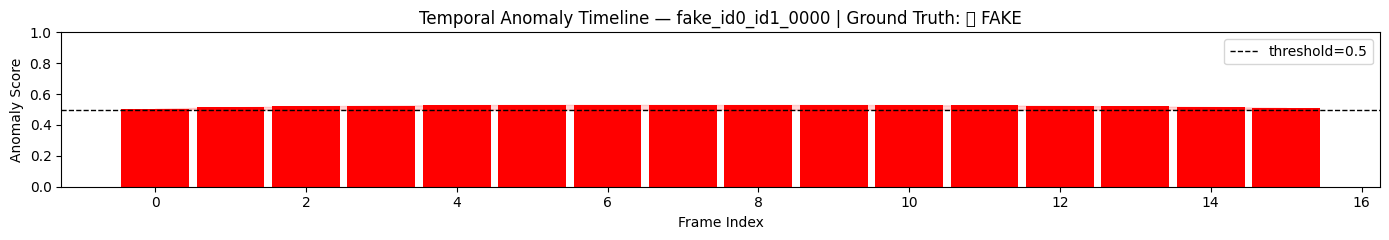

  Saved → /content/drive/MyDrive/Colab Notebooks/deepfake-project/outputs/timelines/fake_id0_id1_0000_timeline.png


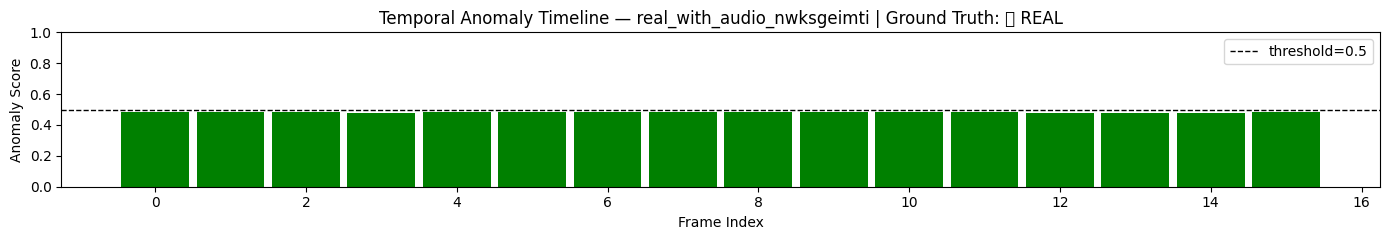

  Saved → /content/drive/MyDrive/Colab Notebooks/deepfake-project/outputs/timelines/real_with_audio_nwksgeimti_timeline.png


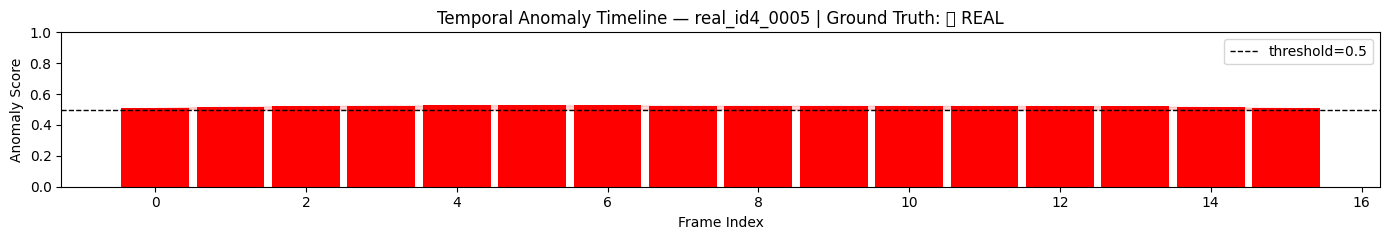

  Saved → /content/drive/MyDrive/Colab Notebooks/deepfake-project/outputs/timelines/real_id4_0005_timeline.png

✅ Timelines saved to /content/drive/MyDrive/Colab Notebooks/deepfake-project/outputs/timelines


In [12]:
# ✅ Cell 11 — Timeline Visualization
def plot_timeline(frame_scores, video_id, label):
    fig, ax = plt.subplots(figsize=(14, 2.5))
    colors  = ["red" if s > 0.5 else "green" for s in frame_scores]
    bars    = ax.bar(range(len(frame_scores)), frame_scores,
                     color=colors, width=0.9, edgecolor="none")
    ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="threshold=0.5")
    ax.fill_between(range(len(frame_scores)),
                    [0.5]*len(frame_scores), frame_scores,
                    where=[s>0.5 for s in frame_scores],
                    alpha=0.15, color="red")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Frame Index")
    ax.set_ylabel("Anomaly Score")
    ax.set_title(f"Temporal Anomaly Timeline — {video_id} | "
                 f"Ground Truth: {'🔴 FAKE' if label else '🟢 REAL'}")
    ax.legend(loc="upper right")
    plt.tight_layout()
    out_path = os.path.join(TIMELINE_DIR, f"{video_id}_timeline.png")
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"  Saved → {out_path}")
    return out_path

# Load best model and show timelines for 3 random validation sequences
model.load_state_dict(torch.load(
    os.path.join(MODEL_DIR, "temporal_lstm.pth"), map_location=DEVICE))
model.eval()

print("Generating timeline visualizations...\n")
sample_indices = random.sample(range(len(va_seqs)), min(3, len(va_seqs)))

for i in sample_indices:
    embs = torch.tensor(
        np.stack([get_embedding(f) for f in va_seqs[i]]),
        dtype=torch.float32
    ).unsqueeze(0).to(DEVICE)

    scores = model.frame_anomaly_scores(embs).squeeze(0).cpu().numpy()
    vid_id = Path(va_seqs[i][0]).stem.replace("_frame_00000", "")[:30]
    plot_timeline(scores, vid_id, va_lbls[i])

print(f"\n✅ Timelines saved to {TIMELINE_DIR}")

In [13]:
# ✅ Cell 12 — Final Check: confirm .pth saved correctly
import os
pth_path = os.path.join(MODEL_DIR, "temporal_lstm.pth")
if os.path.exists(pth_path):
    size_mb = os.path.getsize(pth_path) / 1e6
    print(f"✅ temporal_lstm.pth exists ({size_mb:.1f} MB)")
    print(f"   Location: {pth_path}")
    print("\n🎉 Notebook 06 complete! You can now run notebooks 07, 08, 09 in parallel.")
else:
    print("❌ temporal_lstm.pth NOT found — training may have failed")
    print("   Re-run Cell 10 (training loop)")

✅ temporal_lstm.pth exists (19.5 MB)
   Location: /content/drive/MyDrive/Colab Notebooks/deepfake-project/models/temporal_lstm.pth

🎉 Notebook 06 complete! You can now run notebooks 07, 08, 09 in parallel.
